Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.

В этом задании вам как и раньше нужно выполнить задания, но есть части, где нужно дополнить код и написать **выводы**.
***

In [1]:
import numpy as np
import pandas as pd
import gensim
import matplotlib.pyplot as plt

from nltk.tokenize import WordPunctTokenizer
from nltk.tokenize import TweetTokenizer
from gensim.models import Word2Vec
import gensim.downloader as api
from gensim.models import KeyedVectors

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics.pairwise import cosine_similarity

import bokeh.models as bm, bokeh.plotting as pl
from bokeh.io import output_notebook

# «Теоретическая часть» (3 pt)

В прошлом задании вы поработали с токенизацией и уже неплохо понимаете, что это такое и как ее можно использовать. В этой же домашке мы пойдем дальше и поработаем с **векторным представлением естественного языка**.

Векторному представлению можно посвятить много времени, но наша задача — разобраться в том, как что-то можно использовать, а не погружаться в это слишком глубоко.

***

Вообще подходы к векторному представлению токенов (_тут уже поменяю на токены, вы знаете, что это необязательно слова_) можно очень грубо разделить на две группы (так то их очень [много](https://habr.com/ru/articles/515036/)):
1. **count-base** подходы (насчитывать какие-то статистики и использовать их),
2. **«обучаемые»** векторы (обычно нейросетевые подходы).

> Во второй случай входит очень много чего: это и, отчасти, скрытые представления трансформеров, и какие-то сложные внутренние части моделей. Нас будут интересовать именно те подходы, которые позволяют работать с такими векторами токенов (**эмбеддингами**) как с отдельными сущностями и получать из них информацию.

Среди первых самыми известными и «зафиксированными» являются подходы [**Bow (Bag of words)**](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%88%D0%BE%D0%BA_%D1%81%D0%BB%D0%BE%D0%B2) и [**TF-IDF (Term Frequency — Inverse Document Frequency)**](https://habr.com/ru/companies/otus/articles/755772/). В теоретической части мы их касаться не будем, так как они весьма очевидны, но вот для практической повторите.  
Из вторых мы поговорим только про три популярных и довольно простых метода:
[**Word2Vec**](https://habr.com/ru/articles/446530/),
[**GloVe**](https://en.wikipedia.org/wiki/GloVe) и
[**FastText**](https://www.geeksforgeeks.org/machine-learning/fasttext-working-and-implementation/).

_То, как они работают оставляю на самостоятельное изучение, в этой домашке это не является фокусом, главное — их использование._

И так, начнем с наблюдения сути и работы этих методов.

## Обработка текста (1 pt)

Начнем как обычно с **загрузки данных**, вы уже их знаете, это тот же самый датасет комментариев к видео.

In [15]:
df = pd.read_csv('100000 Youtube comments sentiment dataset.csv').dropna().reset_index(drop=True)
df = df[df['Sentiment'] != 'neutral']

In [16]:
# соединим все в текст, тут нам тональность не нужна, нужен только текст
data = list(df['Comment'])
print(data[:3])

['New fear of elevators unlocked 😖', 'My heart stopped when he almost dropped the iPad 😂', 'That glass brige prank is dangerous. Could make someone fall off the bridge']


In [17]:
# TODO: поэксперементируйте с индексом и найдите интересное предложение с пунктуацией
data[11123]

'Piers- “I’m not mainstream, I’m on YouTube” ok, bud 😂🥴'

### Токенизация

В этом задании мы используем **токенизацию по словам**, чтобы можно было интерпретировать смысл (_в прошлый раз вы скорее всего поняли, что если не слова, то сильно смысла не заметишь_). 

In [18]:
tokenizer = WordPunctTokenizer()
# вставьте тот же индекс
print(tokenizer.tokenize(data[11123]))

['Piers', '-', '“', 'I', '’', 'm', 'not', 'mainstream', ',', 'I', '’', 'm', 'on', 'YouTube', '”', 'ok', ',', 'bud', '😂🥴']


In [19]:
# TODO: токенизируйте все и приведите в нижний регистр
#       должен получиться лист листов токенов каждого предложения
data_tok = [tokenizer.tokenize(line.lower()) for line in data]
print(data_tok[:3])

[['new', 'fear', 'of', 'elevators', 'unlocked', '😖'], ['my', 'heart', 'stopped', 'when', 'he', 'almost', 'dropped', 'the', 'ipad', '😂'], ['that', 'glass', 'brige', 'prank', 'is', 'dangerous', '.', 'could', 'make', 'someone', 'fall', 'off', 'the', 'bridge']]


In [20]:
assert all(isinstance(row, (list, tuple)) for row in data_tok), "please convert each line into a list of tokens (strings)"
assert all(all(isinstance(tok, str) for tok in row) for row in data_tok), "please convert each line into a list of tokens (strings)"
is_latin = lambda tok: all('a' <= x.lower() <= 'z' for x in tok)
assert all(map(lambda l: not is_latin(l) or l.islower(), map(' '.join, data_tok))), "please make sure to lowercase the data"

In [21]:
print(' '.join(data_tok[11123]))

piers - “ i ’ m not mainstream , i ’ m on youtube ” ok , bud 😂🥴


### Создание эмбеддингов

Теперь у нас есть отдельные **токены** и можем их переводить в числовое пространство. Для этого, как уже знаете, есть разные методы: `Word2Vec` и `GloVe` с разными целевыми функциями. Кроме того, есть `FastText`, который использует модели символьного уровня для обучения эмбеддингов.

Выбор огромен, поэтому давайте начнем с малого: `gensim` — это библиотека NLP, которая включает в себя множество векторных моделей, включая `word2vec`.

Самое прекрасное в таких векторах — это то, что они сохраняют семантическое и контекстное значение слова (_Вы точно пример про короля и королеву где-то видели_)! Не будем об этом долго говорить, давайте лучше посмотрим и поймем, что это для нас значит. 

In [22]:
# тут мы обучаем модель, то есть сами создаем эмбеддинги
model = Word2Vec(data_tok, 
                 vector_size=32,      # размер вектора
                 min_count=5,         # минимальная встречаемость слова
                 window=5).wv         # контекстное окно

In [23]:
# теперь можно получать векторы!
model.get_vector('anything')

array([ 1.0046043 ,  2.515861  , -0.16661675,  1.4331212 ,  0.36338192,
        0.68595433,  0.73601884, -0.5791775 , -0.5189519 ,  0.8161937 ,
        0.6321439 ,  0.2767914 , -0.5759485 ,  1.2253267 ,  2.6998413 ,
       -0.02847966,  0.7702792 , -0.48233733,  1.850168  ,  1.4093375 ,
       -1.1546988 , -0.7521222 , -0.69097143, -0.26483825, -0.53434515,
        1.6055373 ,  1.0902447 ,  0.5805709 ,  0.64808977, -0.30577028,
       -1.0431838 ,  0.8832394 ], dtype=float32)

Теперь мы можем поэксперементировать с преимуществами векторного представления! Мы можем посмотреть **похожие в векторном пространстве слова**, а также **поскладывать и по вычитать**!

In [24]:
# TODO: попробуйте разные слова и найдите наиболее интересные!
print(model.most_similar("hate"))

print(model.most_similar("dirty"))

print(model.most_similar("boy"))


[('try', 0.548128604888916), ('thinking', 0.49065932631492615), ('collab', 0.4489944875240326), ('defend', 0.43991774320602417), ('hates', 0.4349130690097809), ('out', 0.4308181405067444), ('watch', 0.40888118743896484), ('thats', 0.4068589508533478), ('watching', 0.4011760652065277), ('even', 0.39830049872398376)]
[('🤧', 0.6708657145500183), ('👇🏾', 0.6564685702323914), ('walk', 0.6384764313697815), ('lets', 0.59629887342453), ('mama', 0.5953564643859863), ('ugh', 0.5624930262565613), ('audience', 0.5524470210075378), ('asf', 0.544664740562439), ('quietly', 0.5345038771629333), ('championship', 0.5337638258934021)]
[('pushed', 0.7080698609352112), ('friend', 0.7066429257392883), ('gestures', 0.6827686429023743), ('algorithms', 0.6671550273895264), ('blue', 0.6522374153137207), ('asap', 0.6481053233146667), ('injured', 0.6282137036323547), ('05', 0.5886437892913818), ('shirt', 0.5875728130340576), ('novel', 0.5867664813995361)]


In [25]:
# TODO: попробуйте разные преобразования с разными парами
#       (это ищет похожее к видео без лайков)
print(model.most_similar(positive=["boy"], negative=["like"]))
print(model.most_similar(positive=["dirty"], negative=["hate"]))

[('girlfriend', 0.6754069328308105), ('17', 0.6595582962036133), ('09', 0.6588614583015442), ('27', 0.6554010510444641), ('pushed', 0.6501299142837524), ('screw', 0.6365517973899841), ('onto', 0.6292009353637695), ('injured', 0.6283103227615356), ('100k', 0.6260656118392944), ('✋', 0.6206961870193481)]
[('mama', 0.6079790592193604), ('steveee', 0.5877410173416138), ('👇🏾', 0.5825567841529846), ('leader', 0.5670550465583801), ('complexity', 0.552513837814331), ('iwata', 0.5511744022369385), ('browsing', 0.5492501258850098), ('🖤', 0.5403971672058105), ('shown', 0.5375133156776428), ('specifically', 0.5371029376983643)]


**ПАРУ СЛОВ О ТОМ, ЧТО ПОЛУЧИЛОСЬ**

так как векторы должны быть близкими в каком-то пространстве, по логике это должны быть синонимы. но да, так как датасет небольшой и со своим контекстом - комменты на ютубе, чаще всего слова именно по смыслу получаются непохожими. например, почему-то слова жена и грязь оказались близкими. единственная более-менее осмысленная пара - boy girlfriend. таким образом схожесть в этом датасете отражает лишь что слова часто встречались в одних и тех же комментариях, но семантического сходства между ними нет.

_Согласитесь, что иногда получается какая-то ерунда... Все потому, что мы учились на весьма конкретном и небольшом корпусе, поэтому и слова для нас не просто слова, а слова именно в этом контексте._

### Использование предобученной модели

Чтобы векторы запоминали больше контекстного смысла, нужно много контекста) То есть нужны большие корпуса текстов и время на обучение. К счастью, в настоящее время вы можете получить предварительно обученную модель эмбеддингов в 2 строки кода.

> После первой загрузки (или при удалении вручную) модель сохраняется в каталоге ~/gensim_data или %USER_PATH%/gensim_data. Это можно проверить, установив для параметра return_path значение True.

In [26]:
# используем другую модель
model_loaded = api.load('glove-twitter-100')

In [27]:
# TODO: проделайте те же эксперименты, что и в прошлой части (слова и пары)
#print(model_loaded.most_similar("hate"))
print(model_loaded.most_similar(positive=["dirty"], negative=["wife"]))
print(model_loaded.most_similar(positive=["boy"], negative=["pushed"]))
model_loaded.most_similar(positive=["coder", "money"], negative=["brain"])

[('muddy', 0.44391193985939026), ('chavy', 0.43523067235946655), ('oldskool', 0.41991370916366577), ('slimy', 0.41882064938545227), ('juggernauts', 0.41631025075912476), ('durty', 0.41559478640556335), ('filthy', 0.4145154356956482), ('getto', 0.4066975712776184), ('funky', 0.40521275997161865), ('trampy', 0.40025269985198975)]
[('macho', 0.474804162979126), ('bebe', 0.47422826290130615), ('mane', 0.4725686311721802), ('tuu', 0.4679398536682129), ('sweet', 0.46790939569473267), ('rt', 0.4652438461780548), ('<heart>', 0.4647839665412903), ('baby', 0.4641779661178589), ('<elong>', 0.46227818727493286), ('<user>', 0.46200767159461975)]


[('broker', 0.5820155739784241),
 ('bonuses', 0.5424473881721497),
 ('banker', 0.5385112762451172),
 ('designer', 0.5197198390960693),
 ('merchandising', 0.4964233338832855),
 ('treet', 0.4922019839286804),
 ('shopper', 0.4920562207698822),
 ('part-time', 0.4912828207015991),
 ('freelance', 0.4843311905860901),
 ('aupair', 0.4796452820301056)]

**ПАРУ СЛОВ О ТОМ, ЧТО ПОЛУЧИЛОСЬ**

если оставить как в предыдущем примере, получится какая-то бессмыслица, иероглифы и прочее. если взять другие слова, то получается что-то более семантически похожее. например boy macho bebe sweet не синонимы, но у них одинковый вайб. dirty oldskool muddy slimy похоже на что-то реперское. в общем модель с предобучением справляется лучше. 

_Теперь мы с одной стороны умеем переводить текст в числа, а с другой — операции с числами что-то интерпретируемое значат как операции со словами._

## Визуализация данных при помощи эмбеддингов (2 pt)

Один из способов узнать, хороши ли наши векторы, — это построить их график. Дело в том, что эти векторы находятся в пространстве более `30D`, а мы, люди, больше привыкли к `2-3D`.

К счастью, мы, изучающие компьютерные технологии, знаем о методах **уменьшения размерности**. Давайте используем это для составления списка из 1000 наиболее часто встречающихся слов.

In [28]:
words = model.index_to_key[:1000] # это модель, которую мы обучили
                                  # параллельно проделайте все то же для загруженной модели!

print(words[::100])

['the', 'by', 'other', 'yeah', 'favorite', 'updates', '😖', '30', 'children', 'corner']


In [29]:
# TODO: для каждого слова посчитайте вектор
word_vectors = np.array([model.get_vector(word) for word in words])

In [30]:
assert isinstance(word_vectors, np.ndarray)
assert word_vectors.shape == (len(words), 32)
assert np.isfinite(word_vectors).all()

### PCA

По классике сначала визуализируем при помощи линейного метода

In [31]:
pca = PCA(n_components=2)
# TODO: обучите pca на word_vectors
word_vectors_pca = pca.fit_transform(word_vectors)
# TODO: отнормируйте векторы
word_vectors_pca = (word_vectors_pca - word_vectors_pca.mean(axis=0)) / word_vectors_pca.std(axis=0)

In [32]:
assert word_vectors_pca.shape == (len(word_vectors), 2), "there must be a 2d vector for each word"
assert max(abs(word_vectors_pca.mean(0))) < 1e-5, "points must be zero-centered"
assert max(abs(1.0 - word_vectors_pca.std(0))) < 1e-2, "points must have unit variance"

In [33]:
# нарисуем их
output_notebook()

def draw_vectors(x, y, radius=10, alpha=0.25, color='blue',
                 width=600, height=400, show=True, **kwargs):
    if isinstance(color, str): color = [color] * len(x)
    data_source = bm.ColumnDataSource({ 'x' : x, 'y' : y, 'color': color, **kwargs })

    fig = pl.figure(active_scroll='wheel_zoom', width=width, height=height)
    fig.scatter('x', 'y', size=radius, color='color', alpha=alpha, source=data_source)

    fig.add_tools(bm.HoverTool(tooltips=[(key, "@" + key) for key in kwargs.keys()]))
    if show: pl.show(fig)
    return fig

Loading BokehJS ...

In [34]:
draw_vectors(word_vectors_pca[:, 0], word_vectors_pca[:, 1], token=words)

figure(id='p1011', ...)

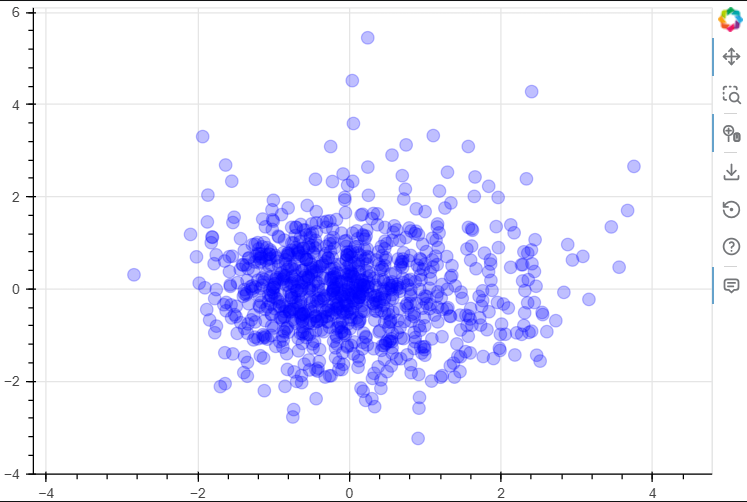

**ВИЗУАЛИЗИРУЙТЕ ТАКЖЕ И ДЛЯ ЗАГРУЖЕННОЙ МОДЕЛИ!**

In [37]:
words_loaded = model_loaded.index_to_key[:1000]

word_vectors_loaded = np.array([model_loaded.get_vector(word) for word in words_loaded])

pca_loaded = PCA(n_components=2)
word_vectors_loaded_pca = pca_loaded.fit_transform(word_vectors_loaded)
word_vectors_loaded_pca = (word_vectors_loaded_pca - word_vectors_loaded_pca.mean(axis=0)) / word_vectors_loaded_pca.std(axis=0)

draw_vectors(word_vectors_loaded_pca[:, 0], word_vectors_loaded_pca[:, 1], token=words_loaded)

figure(id='p1061', ...)

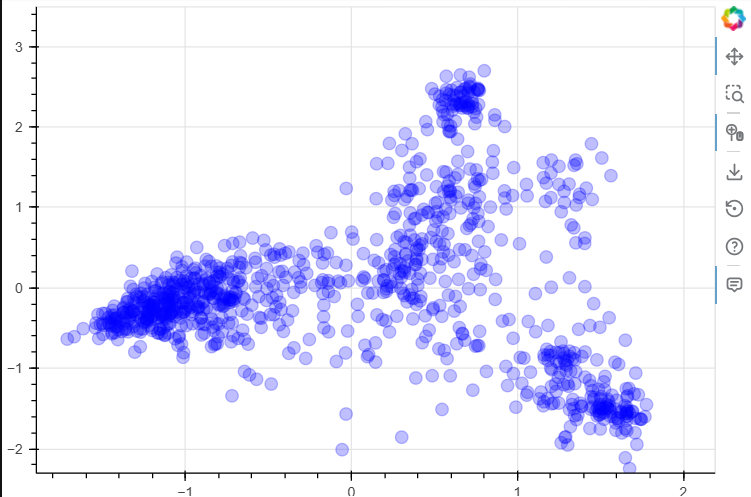

Видны ли группы слов? Можно ли как-то их объяснить?  
**ОТВЕТ**

видно, что у обученной модели всего один кластер, тогда как у модели с предобучением выделяется три кластера и вроде четвертный в центре. у модели с предобучением в центре в основном пунктуация и смайлики, в других кластерах слова или подслова, однако семантического объяснения этому нет.

### t-SNE

Как могли заметить в прошлых домашках, **нелинейные методы круче кластеризуют**, поэтому давайте их попробуем.

In [38]:
# TODO: обучите tsne на word_vectors
tsne = TSNE(n_components=2, random_state=42)
word_tsne = tsne.fit_transform(word_vectors)

In [39]:
draw_vectors(word_tsne[:, 0], word_tsne[:, 1], color='green', token=words)

figure(id='p1111', ...)

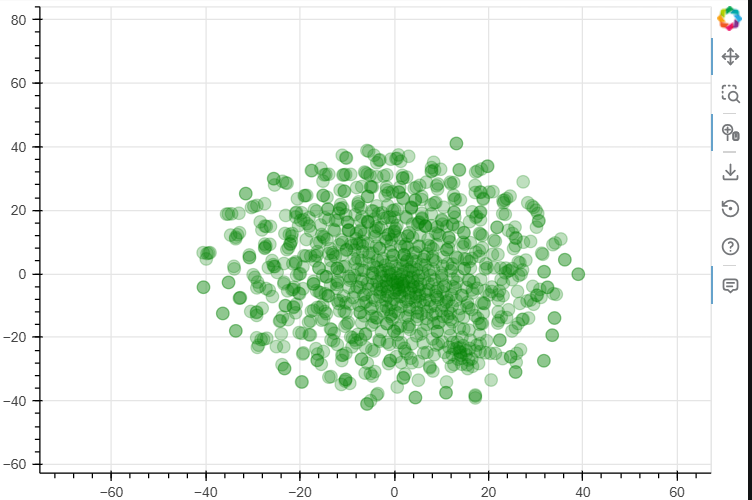

**ВИЗУАЛИЗИРУЙТЕ ТАКЖЕ И ДЛЯ ЗАГРУЖЕННОЙ МОДЕЛИ!**

In [40]:
tsne_loaded = TSNE(n_components=2, random_state=42)
word_tsne_loaded = tsne_loaded.fit_transform(word_vectors_loaded)

draw_vectors(word_tsne_loaded[:, 0], word_tsne_loaded[:, 1], color='green', token=words_loaded)


figure(id='p1161', ...)

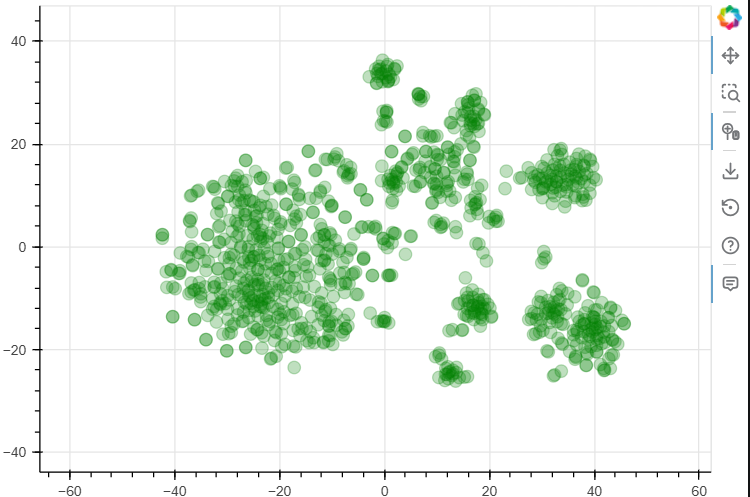

Стали ли группы лучше разделяться? Можно ли как-то объяснить новые группы (если они появились)?  
**ОТВЕТ**

у нашей модели опять просто куча, кластеров нет. а вот у загруежнной модели появилось больше кластеров: какие-то арабские символы, смайлики, предлоги(удивительно, но русские), кластер со смехом ("xd","xaxaxa"), еще кластеры с какими-то языками, предположительно, итальянским и испанским, большой кластер с английскими словами.

_На этом мы закончим с изучением векторов и перейдем к пррррактике!_

# Практическая часть (7 pt)

В этой части вы (мы) повторите задачу прошлой домашки (классификация комментариев). Мы решим эту проблему, используя как **классические методы**, так и подход, основанный на **эмбеддингах**.

_Тут можно рестартнуть ядро, чтобы случаем что-то не затереть и не переиспользовать. Очевидно, что порядок ячеек собъется, в этой домашке норм, если следующая ячейка будет второй и дальше все будет по порядку._

In [2]:
df = pd.read_csv('100000 Youtube comments sentiment dataset.csv').dropna().reset_index(drop=True)
df = df[df['Sentiment'] != 'neutral']
data = df.sample(1_000, random_state=42) # мы уже знаем, что и нашими сууупер простыми методами метрики норм, поэтому возьмем мало данных)

texts = data['Comment'].values
target = data['Sentiment'].values
target = (target == 'Negative').astype(int)

print(pd.Series(target).value_counts())

1    507
0    493
Name: count, dtype: int64


In [3]:
# разделим на трейн и тест, сид и размер не менять,
texts_train, texts_test, y_train, y_test = train_test_split(texts, target, test_size=0.4, random_state=42)

### Обработка и токенизация (0,5 pt)

In [4]:
tokenizer = TweetTokenizer()
preprocess = lambda text: ' '.join(tokenizer.tokenize(text.lower()))

# TODO: обработайте каждое предложение в трейне и тесте

texts_train = [preprocess(text) for text in texts_train]
texts_test = [preprocess(text) for text in texts_test]


In [5]:
assert texts_train[42] ==  "i'm pretty sure a lot of people misses the bro fist wamen and men alike"
assert texts_test[42] == 'a 20lbs girl challenges a badass kickboxer 😂'
assert len(texts_test) == len(y_test)

## BoW (2 pt)

Теперь, когда мы подготовили данные, мы можем переходить к решению задачи.

Один из традиционных подходов к решению заключается в использовании фичей «мешка слов»:
* составьте **словарь часто встречающихся слов** (используйте только обучающие данные),
* для каждого примера из обучающей выборки, подсчитайте, **сколько раз в нем встречается слово** (для каждого слова в словаре),
* считайте этот подсчет **признаками для некоторого классификатора**.

Это можно сделать при помощи реализованных функций, но тут **реализуйте это самостоятельно**.

_Это очень похоже на то, что вы уже делали, только теперь не 0/1, а нормальные числа)_

In [6]:
# TODO: найдите k наиболее часто встречающихся слов в texts_train,
#       отсортируйте их по количество встречаемости (по убыванию)
k = 1000

all_words = [word for text in texts_train for word in text.split()]
bow_vocabulary_dict = {}
for word in all_words:
    if word not in bow_vocabulary_dict:
        bow_vocabulary_dict[word] = 0
    bow_vocabulary_dict[word] += 1

        
sorted_vocabulary = sorted(bow_vocabulary_dict.items(), key=lambda x: x[1], reverse=True)
bow_vocabulary = [word for word, count in sorted_vocabulary[:k]]

print('example features:', sorted(bow_vocabulary)[::100])

example features: ['!', 'baby', 'content', 'explain', 'helen', 'life', 'now', 'ruin', 'take', 'videos']


In [7]:
#TODO: реализуйте функцию, которая преобразует текст в вектор
#      вектор размера словаря, на месте индекса слова стоит количество раз, которое оно встречается в тексте

def text_to_bow(text):
    vector = np.zeros(len(bow_vocabulary), dtype=np.float32)
    for word in text.split():
        if word in bow_vocabulary:
            index = bow_vocabulary.index(word)
            vector[index] += 1
    return vector

    
    return vector

In [8]:
X_train_bow = np.stack(list(map(text_to_bow, texts_train)))
X_test_bow = np.stack(list(map(text_to_bow, texts_test)))

In [9]:
k_max = len(set(' '.join(texts_train).split()))
assert X_train_bow.shape == (len(texts_train), min(k, k_max))
assert X_test_bow.shape == (len(texts_test), min(k, k_max))
assert len(bow_vocabulary) <= min(k, k_max)
assert X_train_bow[6, bow_vocabulary.index('.')] == texts_train[6].split().count('.')

Также как и в прошлый раз используем простую модель

In [10]:
# TODO: подберите подходящие параметры модели
from sklearn.preprocessing import normalize

X_train_bow_norm = normalize(X_train_bow)
X_test_bow_norm = normalize(X_test_bow)

bow_model = LogisticRegression(C=10000, max_iter=1000).fit(X_train_bow_norm, y_train)
acc = np.mean(bow_model.predict(X_test_bow_norm) == y_test)
print(f"acc={acc:.3f}")


acc=0.900


Model accuracy: 0.900
Well done!


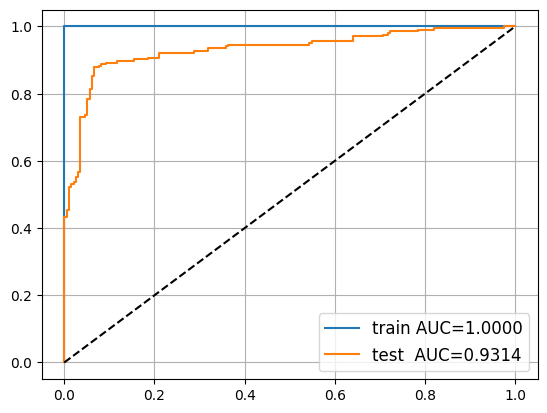

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

for name, X, y, model in [
    ('train', X_train_bow_norm, y_train, bow_model),
    ('test ', X_test_bow_norm, y_test, bow_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(bow_model.predict(X_test_bow_norm) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy >= 0.9, "Hint: tune the parameter C to improve performance"
print("Well done!")


я попробовала много параметров, но ни один не дал 0.9. 
потом я нормализовала данные. потому что есть большие комментарии, которые имеют большое значение признаком, а котороткие - маленькое. нормализация приводит каждый вектор к единичной длине и модель сравнивает относительную частоту слов в тексте, а не абсолютные счетчики. и получилось 0.9

_Не так уж и плохо, правда?) А лучше сможем?_

## TF-IDF (2 pt)

Попробуем применить другой метон создания фич. Интуиция у него такая:

Не все слова одинаково полезны. Можно расставить приоритеты по редким словам и словам пониженного уровня, таким как "и"/"или", используя функции **tf-idf**. Эта аббревиатура расшифровывается как **частота текста/обратная частота документа** и означает именно это:

$$ \text{feature}_i = \frac{\text{Count}(word_i \in x)}{\text{Total number of words in } x} \times \log\left(\frac{N}{\text{Count}(word_i \in D) + \alpha}\right),$$

где $x$ — отдельный текст, $D$ — ваш набор данных (коллекция текстов), $N$ — общее количество документов, а $\alpha$ — гиперпараметр сглаживания (обычно 1). А $Count(word_i \in D)$ - это количество документов, в которых фигурирует $word_i$.

Также может быть хорошей идеей нормализовать каждый пример после вычисления функций tf-idf.

In [12]:
# TODO: реализовать TF-IDF, размерность оставить как в прошлом примере

vocabulary_count_dict = {word: count for word, count in sorted_vocabulary[:k]}
N = len(texts_train)
alpha = 1

def text_to_tf_idf(text):
    vector = np.zeros(len(vocabulary_count_dict), dtype=np.float32)
    words = text.split()
    total_words = len(words)
    
    if total_words == 0:
        return vector
    
    # считаем сколько раз каждое слово встречается в тексте
    text_vocabulary_count_dict = {}
    for word in words:
        if word in vocabulary_count_dict:
            if word not in text_vocabulary_count_dict:
                text_vocabulary_count_dict[word] = 0
            text_vocabulary_count_dict[word] += 1
    
    vocab_list = list(vocabulary_count_dict.keys())
    
    for word, count in text_vocabulary_count_dict.items():
        idx = vocab_list.index(word)
        tf = count / total_words
        idf = np.log(N / (vocabulary_count_dict[word] + alpha))
        vector[idx] = tf * idf
    
    return vector


In [13]:
X_train_tfidf = np.stack(list(map(text_to_tf_idf, texts_train)))
X_test_tfidf = np.stack(list(map(text_to_tf_idf, texts_test)))

In [14]:
tfidf_model = LogisticRegression(random_state=42).fit(X_train_tfidf, y_train) 

Model accuracy: 0.825


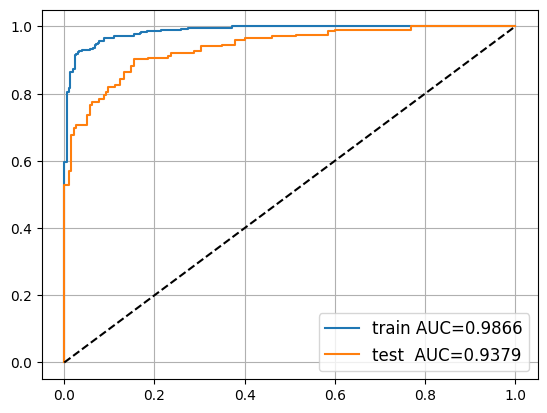

In [15]:
for name, X, y, model in [
    ('train', X_train_tfidf, y_train, tfidf_model),
    ('test ', X_test_tfidf, y_test, tfidf_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(tfidf_model.predict(X_test_tfidf) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")

**ЗАДАНИЕ**: сравните полученные модели и метрики, какие минусы у этих моделей?

BoW достигает accuracy=0.90 но сильно переобучается (train AUC=1.0  test AUC=0.93). TF-IDF менее склонна к переобучению, кривые train/test ближе, но итоговая точность ниже (0.825). Оба метода игнорируют смысл и порядок слов, не справляются с морфологией и синонимами, слова вне фиксированного словаря топ-1000 полностью игнорируются.

## Fasttext (1,5 pt)

Пойдем дальше и используем векторизацию, которая оставляет семантический смысл предложений!

Вместо подсчета частот для каждого слова, мы сопоставим все слова с **заранее подготовленными векторами** слов и **усредним по ним**, чтобы получить текстовые характеристики предложения. 

* Во-первых, мы так сможем работать даже с теми словами, которых нет в обучающей выборке.
* Во-вторых, мы можем работать в меньшей размерности.

Как и ранее будем использовать предобученную модель для получения эмбеддингов.

In [16]:
embeddings = api.load('fasttext-wiki-news-subwords-300')

In [17]:
# TODO: реализуйте функцию, которая преобразует текст в сумму векторов токенов

def vectorize_sum(text):
    embedding_dim = embeddings.vectors.shape[1]
    features = np.zeros([embedding_dim], dtype='float32')
    
    for word in text.split():
        if word in embeddings:
            features += embeddings[word]
    
    return features


assert np.allclose(
    vectorize_sum("who cares anymore . they attack with impunity .")[::70],
    np.array([ 0.0108616 ,  0.0261663 ,  0.13855131, -0.18510573, -0.46380025])
)

In [18]:
X_train_ft = np.stack([vectorize_sum(text) for text in texts_train])
X_test_ft = np.stack([vectorize_sum(text) for text in texts_test])

c:\Users\pochi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model accuracy: 0.910


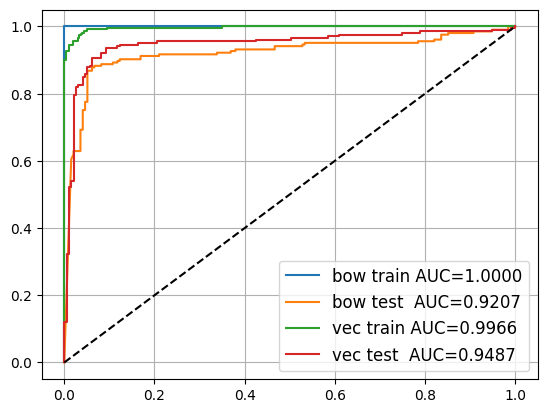

In [19]:
ft_model = LogisticRegression(random_state=42).fit(X_train_ft, y_train) # поэксперементируйте с параметрами

for name, X, y, model in [
    ('bow train', X_train_bow, y_train, bow_model),
    ('bow test ', X_test_bow, y_test, bow_model),
    ('vec train', X_train_ft, y_train, ft_model),
    ('vec test ', X_test_ft, y_test, ft_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(ft_model.predict(X_test_ft) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")

_Ну как?_

BoW переобучается сильнее (train AUC=1.0, test AUC=0.92), FastText-эмбеддинги дают лучшее качество на тесте (AUC=0.95, accuracy=0.91) при меньшем переобучении. FastText учитывает семантику, поэтому результат лучше.

## Использование не для машинного обучения (1 pt)

Пока мы с вами поиспользовали векторы предложений только для обучения, но давайте попробуем использовать и для «визуального» анализа наших данных!

Давайте попробуем научиться определять **наиболее похожее по смыслу предложение** из нашего корпуса (или топ таких)!

Для этого будем задавать смысл в виде строки, считать его вектор, а затем по **косиносному расстоянию** искать самые похожие предложения в данных. Это практически то же, что мы делали и в теоретичекой части.

In [20]:
qwery = "It's the most beautiful thing I've seen."
qwery = ' '.join(tokenizer.tokenize(qwery.lower()))

bow_vec = text_to_bow(qwery)
tfidf_vec = text_to_tf_idf(qwery)
ft_vec = vectorize_sum(qwery)
print(bow_vec[:10], tfidf_vec[:10], ft_vec[:10])
print(len(bow_vec), len(tfidf_vec), len(ft_vec))
# посмотрите на значения векторов, что думаете?

[1. 0. 0. 0. 0. 1. 0. 0. 0. 0.] [0.06042833 0.         0.         0.         0.         0.12260365
 0.         0.         0.         0.        ] [-0.00477628 -0.0598513   0.1257994   0.0487193  -0.1361466  -0.08978272
 -0.0696388  -0.37935597 -0.30171898 -0.0327442 ]
1000 1000 300


BoW/TF-IDF — очень разреженные: почти все нули, редкие ненулевые значения где слова из словаря
FastText плотный: все 300 чисел ненулевые, числа от -2 до +2
BoW/TF-IDF кодируют только присутствие конкретных слов. У FastText каждое измерение что-то значит в семантическом пространстве.

In [21]:
def find_similar_comments(query_vec, comment_embeddings, comment_texts=texts_train, top_n=5):
    
    query_vec = query_vec.reshape(1, -1)
    
    similarities = cosine_similarity(query_vec, comment_embeddings)[0] #возвращает матрицу, но в ней одна строка, поэотму просто берем ее
    
    sorted_indices = np.argsort(similarities) #сортируем
    top_indices = sorted_indices[::-1][:top_n] #переворачиваем и берем топ
    
    results = []
    for idx in top_indices:
        results.append({
            'text': comment_texts[idx],
            'similarity': similarities[idx]
        })
    
    return results


In [22]:
bow_sims = find_similar_comments(bow_vec, X_train_bow)

for res in bow_sims:
    print(f"{res['text']} | similarity = {res['similarity']:.4f}\n")

that was seriously the most enjoyable thing ive seen in awhile i forgot how rad this channel is well done sir | similarity = 0.3430

i agree with him . i said the same thing when this broke out . they should ‘ at least ’ tell the customers that the update can be result in bad performance . i ’ m writing this with my sluggish iphone 5s . | similarity = 0.3266

i agree with him . i said the same thing when this broke out . they should ‘ at least ’ tell the customers that the update can be result in bad performance . i ’ m writing this with my sluggish iphone 5s . | similarity = 0.3266

telling you honestly , i do not agree with the 48 laws of power because the book contradicts itself . it made the readers more confused . the conclusion of the book is that it is a compilation of a bunch of quotes which contradict themselves . | similarity = 0.3050

depends on the performance . if it's really bad , then performance . if it's 15-25 % less performance then sure , but i'd love to be able to s

похоже только первое

In [23]:
tfidf_sims = find_similar_comments(tfidf_vec, X_train_tfidf)

for res in tfidf_sims:
    print(f"{res['text']} | similarity = {res['similarity']:.4f}\n")

this was absolutely beautiful | similarity = 0.3988

that was seriously the most enjoyable thing ive seen in awhile i forgot how rad this channel is well done sir | similarity = 0.3135

there's time for this book , just as a thing to know , although basics are always the most important | similarity = 0.2351

ive seen terribly executed fake versions of this but your videos are by far the most authentic and hilarious omegle skip prank videos | similarity = 0.2295

😂 😂 😂 this is the funniest thing i've seen in a long time lol . i absolutely enjoyed this 🤣 🤣 🤣 😂 😂 😂 | similarity = 0.2214



все предложения похожи

In [24]:
ft_sims = find_similar_comments(ft_vec, X_train_ft)

for res in ft_sims:
    print(f"{res['text']} | similarity = {res['similarity']:.4f}\n")

never liked mukbang , never saw mukbang , never enjoyed mukbang . always wondered how are these mukbangers still so skinny . finally realised the truth , only the face is the fully visible part of their whole body and that's how they trick everybody . and now after nikocado avocado's reveal i am shocked . | similarity = 0.9033

there isn't much that shocks me these days but oh my days this is awful . money truly is the worst of all things . | similarity = 0.8953

telling you honestly , i do not agree with the 48 laws of power because the book contradicts itself . it made the readers more confused . the conclusion of the book is that it is a compilation of a bunch of quotes which contradict themselves . | similarity = 0.8908

very good video man . still just as valid as ever . | similarity = 0.8850

very good video man . still just as valid as ever . | similarity = 0.8850



по смыслу только 4-5 близко

**ВОПРОС**: что лучше подходит, можно ли как-то это использовать при анализе текстовых данных?

больше всего подходит tfidf, скорее всего это из-за того, как устроена сама модель: она понижает вес частых слов по всей обучающей выборке, поэтому служебные слова имеют низкий вес и не засоряют сходство. а FastText обучается на других данных поэтому может в этом датесете ему было сложно найти похожие по смыслу слова. ну а про bow вообще нет смысла говорить, потому что в самом предложении с которым мы сравнимаем много всяких служебных слов, а bow с этим никак не борется.

***
_ну все, конец_